<a href="https://colab.research.google.com/github/nitesh742/northstar-/blob/main/NorthStar_Database_Analytics_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving northstar_dataset (1).zip to northstar_dataset (1).zip


In [5]:
import zipfile
import os

zip_path = "northstar_dataset (1).zip"

extract_path = "/content/northstar_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)

['northstar_dataset']

In [9]:
import pandas as pd

customers = pd.read_csv("/content/northstar_dataset/northstar_dataset/customers.csv")
orders = pd.read_csv("/content/northstar_dataset/northstar_dataset/orders.csv")
deliveries = pd.read_csv("/content/northstar_dataset/northstar_dataset/deliveries.csv")
complaints = pd.read_csv("/content/northstar_dataset/northstar_dataset/complaints.csv")
drivers = pd.read_csv("/content/northstar_dataset/northstar_dataset/drivers.csv")
vehicles = pd.read_csv("/content/northstar_dataset/northstar_dataset/vehicles.csv")
incidents = pd.read_csv("/content/northstar_dataset/northstar_dataset/incidents.csv")
hubs = pd.read_csv("/content/northstar_dataset/northstar_dataset/hubs.csv")
app_events = pd.read_csv("/content/northstar_dataset/northstar_dataset/app_events.csv")

In [11]:
customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [13]:
for name, df in {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "complaints": complaints,
    "drivers": drivers,
    "vehicles": vehicles,
    "incidents": incidents,
    "hubs": hubs,
    "app_events": app_events
}.items():
    print("\n", name)
    print(df.columns)


 customers
Index(['customer_id', 'age', 'home_zone', 'customer_type', 'signup_date',
       'loyalty_score', 'app_engagement_score', 'preferred_channel',
       'account_status'],
      dtype='object')

 orders
Index(['order_id', 'customer_id', 'service_type', 'order_created_at',
       'promised_window_hours', 'pickup_zone', 'dropoff_zone',
       'priority_level', 'order_value', 'booking_channel',
       'special_handling_flag'],
      dtype='object')

 deliveries
Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')

 complaints
Index(['complaint_id', 'customer_id', 'order_id', 'complaint_type', 'channel',
       'severity', 'created_at', 'status', 'resolution_days',
       'compensation_amount'],
      dtype='object')

In [15]:
datasets = [customers, orders, deliveries, complaints, drivers, vehicles, incidents, hubs, app_events]

for df in datasets:
    df.drop_duplicates(inplace=True)

customers.isnull().sum()

,0
customer_id,0
age,0
home_zone,0
customer_type,0
signup_date,0
loyalty_score,20
app_engagement_score,0
preferred_channel,13
account_status,0


In [18]:
complaints_with_zones = pd.merge(complaints, customers[['customer_id', 'home_zone']], on='customer_id', how='left')
complaints_by_zone = complaints_with_zones.groupby('home_zone').size().reset_index(name='total_complaints')
complaints_by_zone.sort_values('total_complaints', ascending=False)

,home_zone,total_complaints
11,SOUTH,33
2,CENTRAL,24
8,North,24
9,RiverSide,24
6,East,23
10,Riverside,21
15,north,21
7,NORTH,19
1,Airport,19
14,West,19


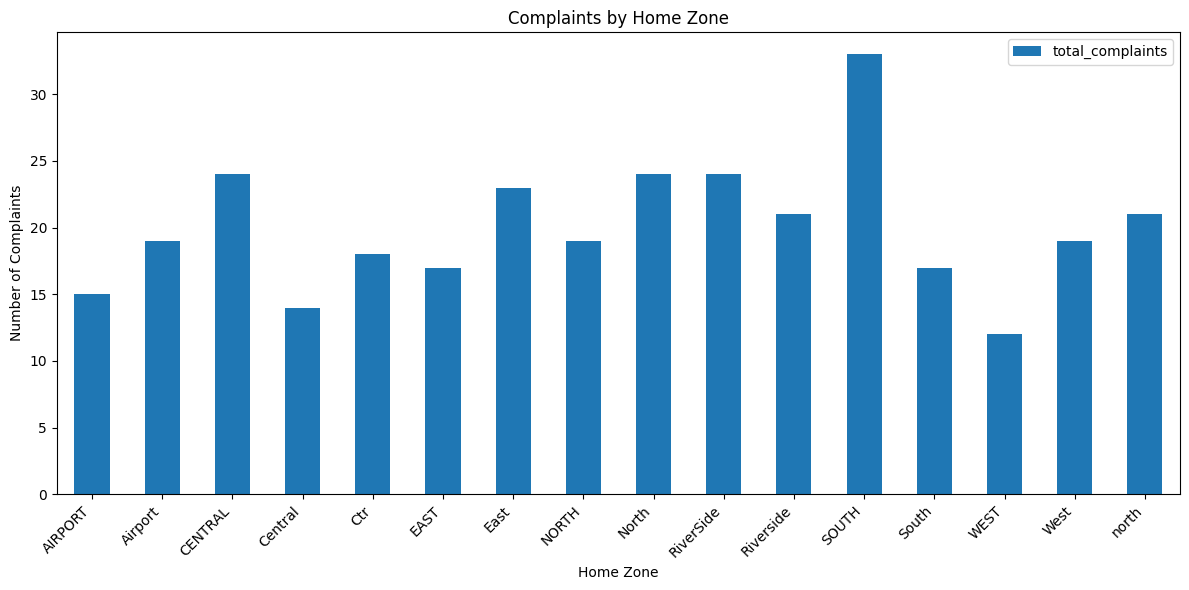

In [21]:
import matplotlib.pyplot as plt

complaints_by_zone.plot(kind="bar", x="home_zone", y="total_complaints", figsize=(12, 6))
plt.title("Complaints by Home Zone")
plt.xlabel("Home Zone")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
delivery_status = deliveries["delivery_status"].value_counts()
delivery_status

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


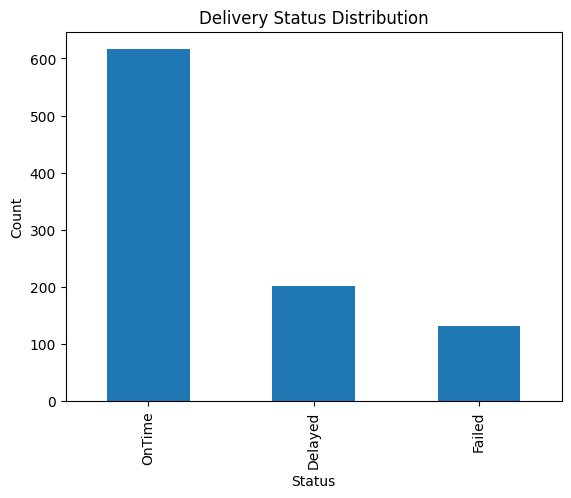

In [25]:
delivery_status.plot(kind="bar")
plt.title("Delivery Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [27]:
!pip install pandasql

In [29]:
from pandasql import sqldf

query = """
SELECT
    c.home_zone,
    COUNT(*) AS total_complaints
FROM
    complaints AS comp
INNER JOIN
    customers AS c ON comp.customer_id = c.customer_id
GROUP BY
    c.home_zone
ORDER BY
    total_complaints DESC
"""

result = sqldf(query)
result

,home_zone,total_complaints
0,SOUTH,33
1,RiverSide,24
2,North,24
3,CENTRAL,24
4,East,23
5,north,21
6,Riverside,21
7,West,19
8,NORTH,19
9,Airport,19
